<a href="https://colab.research.google.com/github/romialcoba/challenge_telecomx_latam/blob/main/telecomx_latam_ra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto TelecomXLATAM

##📌 Extracción

**1- Extracción de datos**

Cargar los datos directamente desde la API utilizando Python.

Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json

In [1]:
import pandas as pd

# URL de la API proporcionada
data_url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

# Cargar los datos desde la URL a un DataFrame de Pandas
df = pd.read_json(data_url)

# Mostrar las primeras 5 filas del DataFrame
display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##🔧 Transformación

**2-Conoce el conjunto de datos**

Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

📌 Para facilitar este proceso, hemos creado un diccionario de datos con la descripción de cada columna. Aunque no es obligatorio utilizarlo, puede ayudarte a comprender mejor la información disponible.



¿Qué debes hacer?

✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

### Aplanando las columnas anidadas

El DataFrame actual contiene columnas como 'customer', 'phone', 'internet' y 'account' que almacenan diccionarios. Para facilitar el análisis, es necesario aplanar estas columnas, extrayendo sus claves como nuevas columnas individuales en el DataFrame principal.

In [2]:
# Función para aplanar columnas anidadas
def flatten_json_column(df, column_name):
    # Normalizar la columna anidada
    df_normalized = pd.json_normalize(df[column_name])
    # Renombrar las columnas para evitar conflictos y claridad
    df_normalized.columns = [f'{column_name}_{col}' for col in df_normalized.columns]
    # Unir el DataFrame normalizado con el original y eliminar la columna original
    df = pd.concat([df, df_normalized], axis=1).drop(columns=[column_name])
    return df

# Aplanar las columnas 'customer', 'phone', 'internet' y 'account'
df = flatten_json_column(df, 'customer')
df = flatten_json_column(df, 'phone')
df = flatten_json_column(df, 'internet')
df = flatten_json_column(df, 'account')

# Mostrar las primeras 5 filas del DataFrame aplanado para verificar
display(df.head())

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### Exploración de columnas y tipos de datos

Ahora que las columnas anidadas han sido aplanadas, vamos a explorar la estructura del DataFrame, verificar los tipos de datos de cada columna y ver si hay valores nulos. Esto nos ayudará a comprender mejor el dataset y a identificar posibles problemas para el análisis de evasión.

In [3]:
# Mostrar información del DataFrame (columnas, tipos de datos, valores no nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

### Resumen de la exploración inicial

Tras aplanar las columnas anidadas y revisar `df.info()`, podemos observar lo siguiente:

*   **Tipos de datos:** La mayoría de las columnas son de tipo `object`, lo que sugiere que son cadenas de texto o datos categóricos. Algunas columnas numéricas, como `customer_SeniorCitizen`, `tenure`, `account_Charges.Monthly`, ya tienen tipos de datos apropiados.
*   **Valores nulos:** Es importante revisar si hay columnas con un número significativo de valores nulos que puedan requerir un tratamiento especial. La salida de `df.info()` nos muestra cuántos valores no nulos hay en cada columna.
*   **Columna `account_Charges.Total`:** Esta columna es de tipo `object`. Es probable que contenga valores no numéricos (como espacios en blanco o texto) que impidan su conversión directa a un tipo numérico (float o int). Será necesario limpiarla y convertirla.

### Identificación de columnas relevantes para el análisis de evasión

Considerando el diccionario de datos proporcionado, las columnas más relevantes para predecir la evasión de clientes (`Churn`) son:

*   `Churn`: La variable objetivo a predecir.
*   `customer_gender`, `customer_SeniorCitizen`, `customer_Partner`, `customer_Dependents`: Demografía del cliente.
*   `tenure`: Duración de la permanencia del cliente.
*   `phone_PhoneService`, `phone_MultipleLines`: Servicios telefónicos.
*   `internet_InternetService`, `internet_OnlineSecurity`, `internet_OnlineBackup`, `internet_DeviceProtection`, `internet_TechSupport`, `internet_StreamingTV`, `internet_StreamingMovies`: Servicios de internet y complementos.
*   `account_Contract`, `account_PaperlessBilling`, `account_PaymentMethod`: Detalles del contrato y facturación.
*   `account_Charges.Monthly`, `account_Charges.Total`: Importes de cargos mensuales y totales.

### Limpieza y Conversión de `account_Charges.Total`

Como se observó, la columna `account_Charges.Total` es de tipo `object` a pesar de que debería ser numérica. Esto indica la presencia de valores no numéricos. Procederemos a limpiar esta columna reemplazando los espacios en blanco con `NaN` y luego convirtiéndola a tipo `float`. Finalmente, imputaremos los valores `NaN` con cero, asumiendo que los clientes con `NaN` en `account_Charges.Total` tienen 0 cargos totales.

In [4]:
# Reemplazar espacios en blanco con NaN y convertir a tipo numérico
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')

# Imputar los valores NaN resultantes con 0 (ya que son casos donde probablemente no hay cargos totales aún)
df['account_Charges.Total'] = df['account_Charges.Total'].fillna(0)

# Verificar el tipo de datos y las primeras filas para confirmar la transformación
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

None

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


**3 -Comprobación de incoherencias en los datos**

En este paso, verifica si hay problemas en los datos que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.

📌 Tips:

pandas.unique()

pandas.Series.dt.normalize()

**4-Manejo de inconsistencias**

Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

📌 Tips:

Manipulación de strings en pandas: lower, replace, startswith y contains

### Verificar valores ausentes

Se revisa explícitamente si existen valores nulos en el DataFrame después de las transformaciones realizadas.


In [5]:
print("Valores nulos por columna después de las transformaciones:")
print(df.isnull().sum())

Valores nulos por columna después de las transformaciones:
customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges.Monthly      0
account_Charges.Total        0
dtype: int64


###Identificar y contar filas duplicadas

Se identifica y cuenta todas las filas completamente duplicadas en el DataFrame `df` para evaluar la existencia de registros idénticos.

In [6]:
print(f"Número de filas duplicadas: {df.duplicated().sum()}")

Número de filas duplicadas: 0


###Exploración de valores únicos en columnas categóricas

Se explora los valores únicos en todas las columnas de tipo `object` para detectar inconsistencias, errores de formato o categorías que requieran unificación. Esto es crucial para la calidad de los datos antes de cualquier análisis o modelado.



In [7]:
for column in df.select_dtypes(include='object').columns:
    print(f"\nUnique values for column '{column}':")
    print(df[column].unique())



Unique values for column 'customerID':
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Unique values for column 'Churn':
['No' 'Yes' '']

Unique values for column 'customer_gender':
['Female' 'Male']

Unique values for column 'customer_Partner':
['Yes' 'No']

Unique values for column 'customer_Dependents':
['Yes' 'No']

Unique values for column 'phone_PhoneService':
['Yes' 'No']

Unique values for column 'phone_MultipleLines':
['No' 'Yes' 'No phone service']

Unique values for column 'internet_InternetService':
['DSL' 'Fiber optic' 'No']

Unique values for column 'internet_OnlineSecurity':
['No' 'Yes' 'No internet service']

Unique values for column 'internet_OnlineBackup':
['Yes' 'No' 'No internet service']

Unique values for column 'internet_DeviceProtection':
['No' 'Yes' 'No internet service']

Unique values for column 'internet_TechSupport':
['Yes' 'No' 'No internet service']

Unique values for column 'internet_StreamingTV':
['Yes' 'No' 'No in

### Corrección de inconsistencias en la columna 'Churn'

La exploración de valores únicos en las columnas de tipo `object` reveló que la columna `Churn` contiene un valor de cadena vacía (`''`). Dado que `Churn` es la variable objetivo y debe ser binaria ('Yes' o 'No'), una cadena vacía representa una inconsistencia que debe ser tratada.

**Vamos a:**
1.  Identificar las filas donde la columna `Churn` tiene el valor de cadena vacía `''`.
2.  Eliminar estas filas del DataFrame, ya que un valor inconsistente en la variable objetivo puede sesgar el análisis y el modelado.

In [8]:
df = df[df['Churn'] != '']

print("Unique values for column 'Churn' after correction:")
print(df['Churn'].unique())

display(df.info())
display(df.head())

Unique values for column 'Churn' after correction:
['No' 'Yes']
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   object 
 5   customer_Dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   object 
 8   phone_MultipleLines        7043 non-null   object 
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   object 
 11  internet_OnlineBackup      7043 non-null   object 
 12  internet_DeviceProtection  7043 non-null   ob

None

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


##📊 Carga y análisis

**5-Análisis Descriptivo**

Para comenzar, realiza un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 Consejos:

usa describe()

**6- Distribución de evasión**

En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

**7-Recuento de evasión por variables categóricas**

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

**8-Conteo de evasión por variables numéricas**

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

**9- Informe Final**

Finaliza el desafío elaborando un informe dentro del mismo notebook que resuma todo el trabajo realizado. El informe debe incluir:

🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).

🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.

### Análisis Descriptivo General

Se realiza un análisis descriptivo del DataFrame completo utilizando `df.describe()` para obtener métricas estadísticas clave de las columnas numéricas. Además, explorar la distribución de las columnas categóricas con `value_counts()`.


In [9]:
print("\n--- Descriptive Statistics for Numerical Columns ---")
display(df.describe())

print("\n--- Value Counts for Categorical Columns ---")
for column in df.select_dtypes(include='object').columns:
    print(f"\nValue counts for column '{column}':")
    display(df[column].value_counts())



--- Descriptive Statistics for Numerical Columns ---


,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000



--- Value Counts for Categorical Columns ---

Value counts for column 'customerID':


,count
customerID,
9995-HOTOH,1
0002-ORFBO,1
0003-MKNFE,1
9970-QBCDA,1
9968-FFVVH,1
...,...
0014-BMAQU,1
0013-SMEOE,1
0013-MHZWF,1



Value counts for column 'Churn':


...

,count
account_Contract,
Month-to-month,3875
Two year,1695
One year,1473



Value counts for column 'account_PaperlessBilling':


,count
account_PaperlessBilling,
Yes,4171
No,2872



Value counts for column 'account_PaymentMethod':


,count
account_PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


### Análisis de Distribución de Evasión (Churn)

Se visualiza la distribución de la variable 'Churn' para entender la proporción de clientes que han evadido y los que no. Se utilizará un gráfico de barras o pastel para representar esta distribución.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_191/3056498045.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


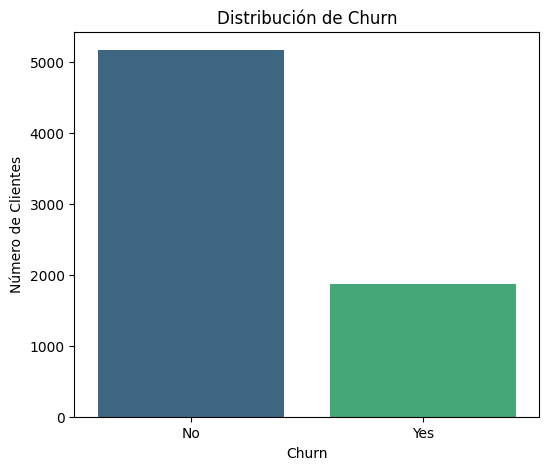

In [11]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

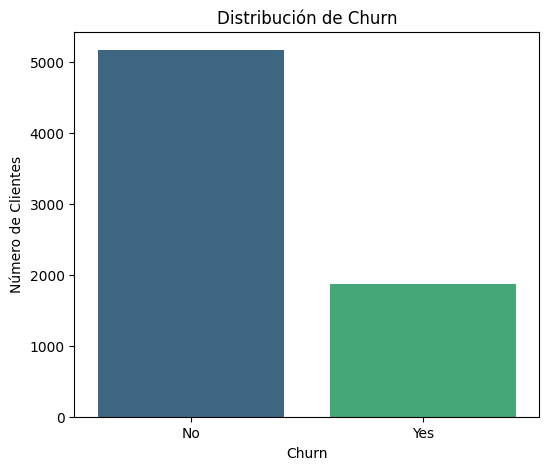

In [12]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', hue='Churn', data=df, palette='viridis', legend=False)
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

### Recuento de Evasión por Variables Categóricas

Se analiza la relación entre la evasión ('Churn') y las variables categóricas clave (como género, SeniorCitizen, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod). Se crearán gráficos (por ejemplo, de barras apiladas) para visualizar la proporción de Churn en cada categoría.


In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

print("Categorical columns for churn analysis:")
print(categorical_cols)

Categorical columns for churn analysis:
['customer_gender', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod']


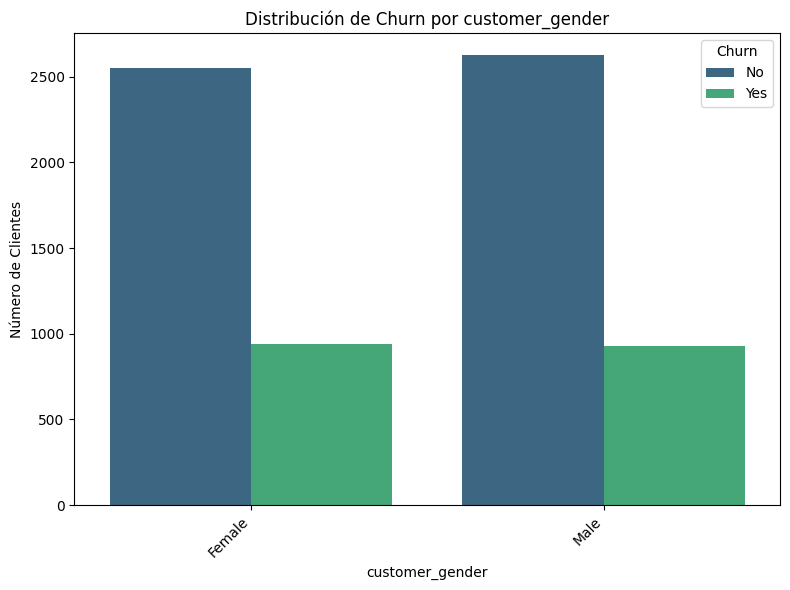

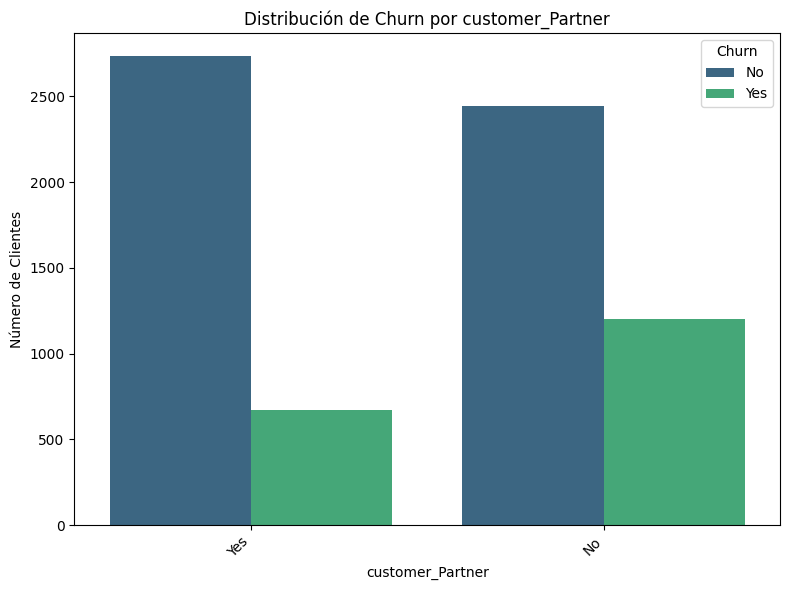

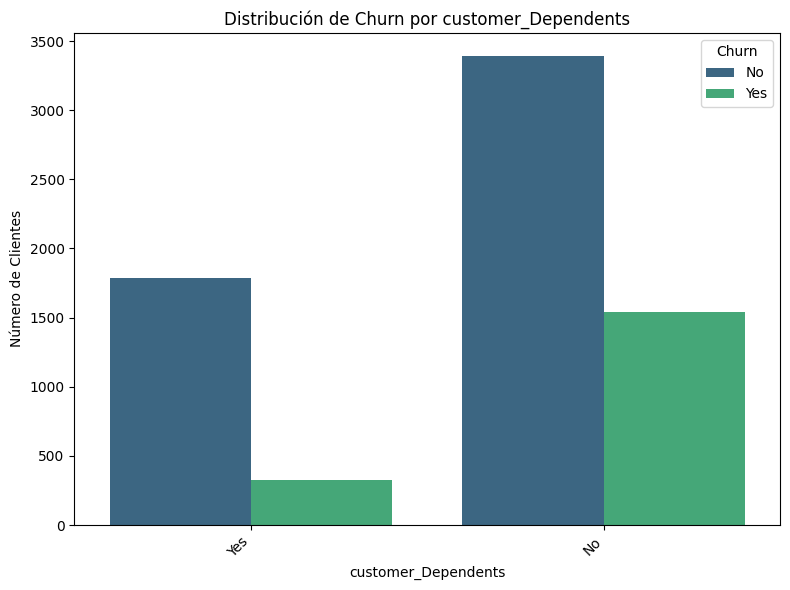

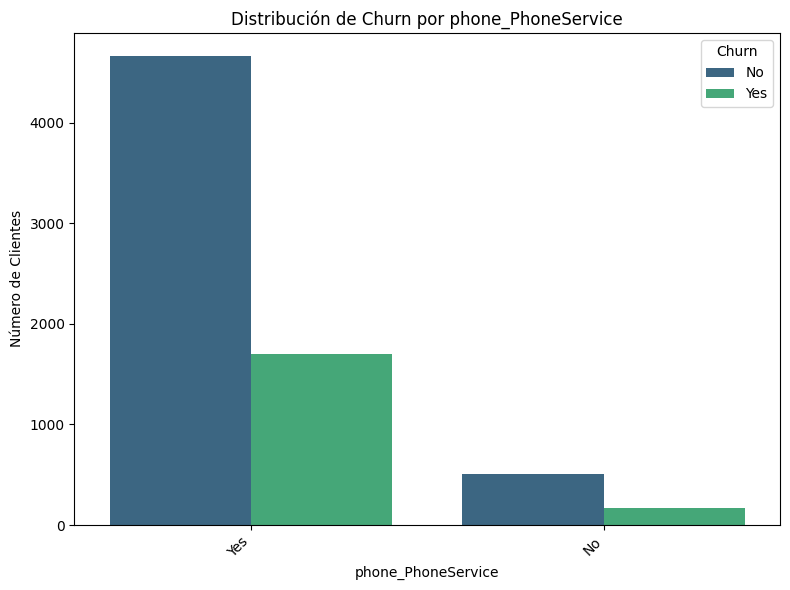

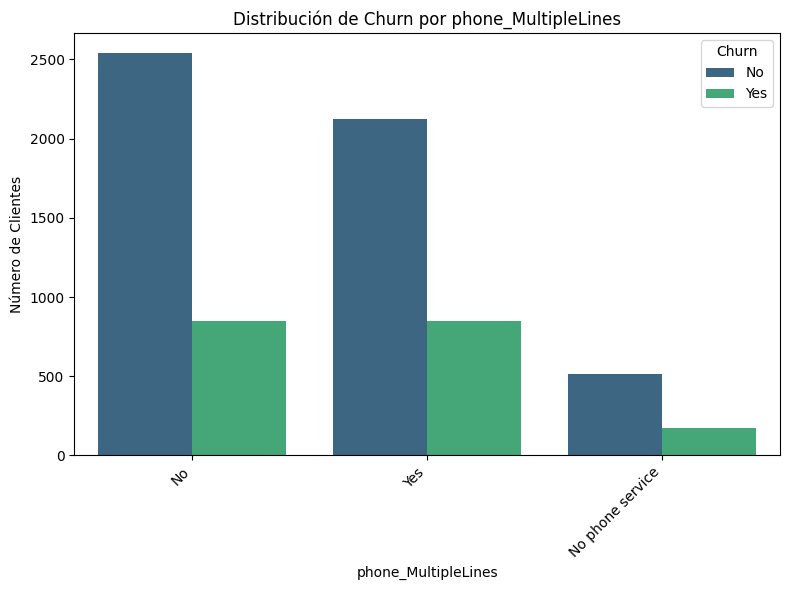

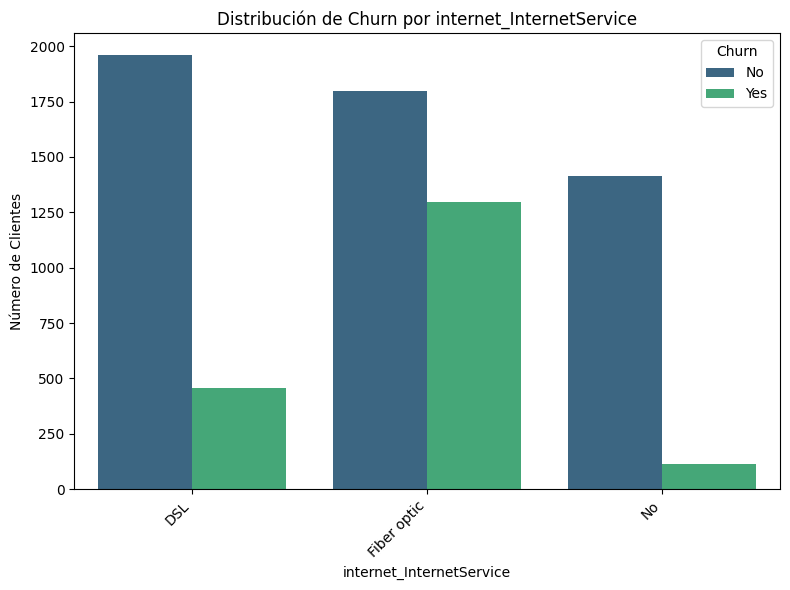

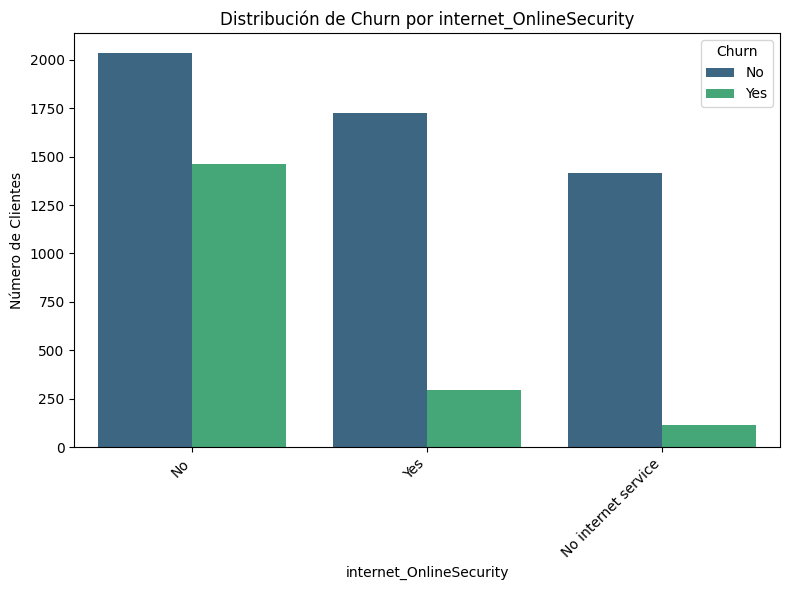

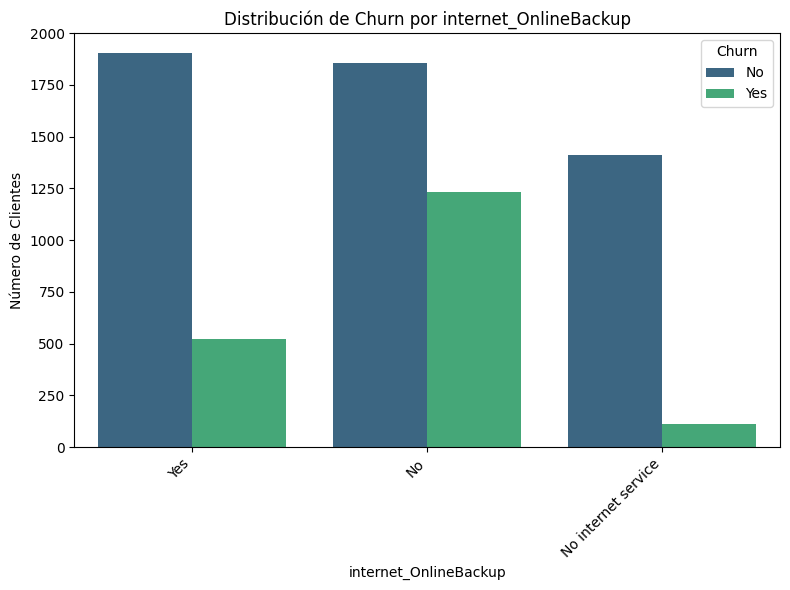

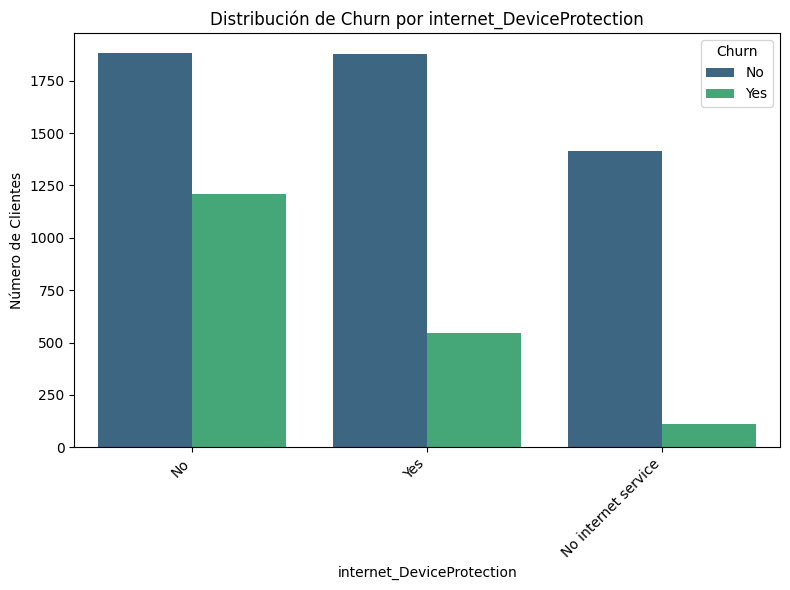

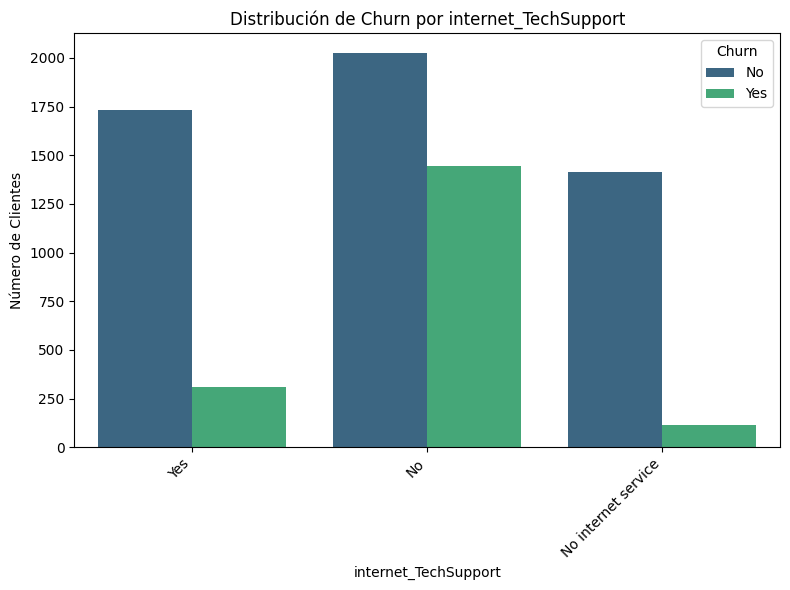

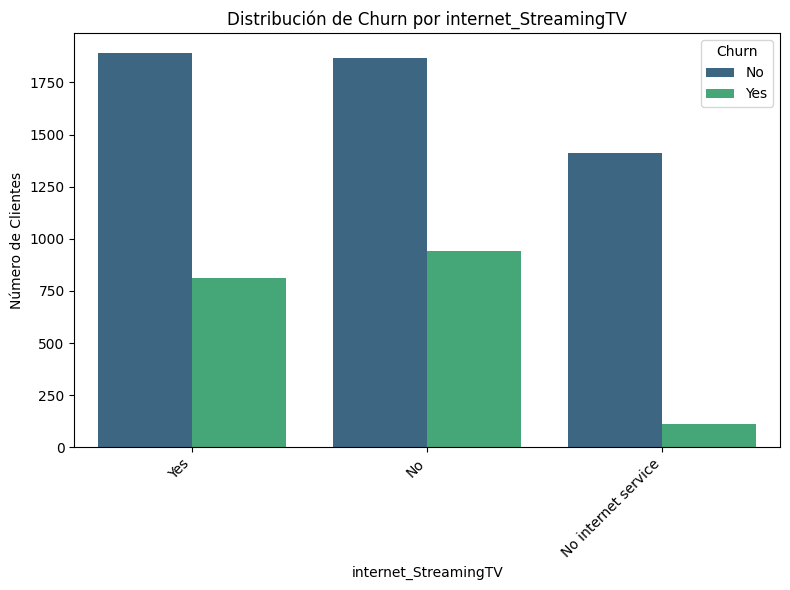

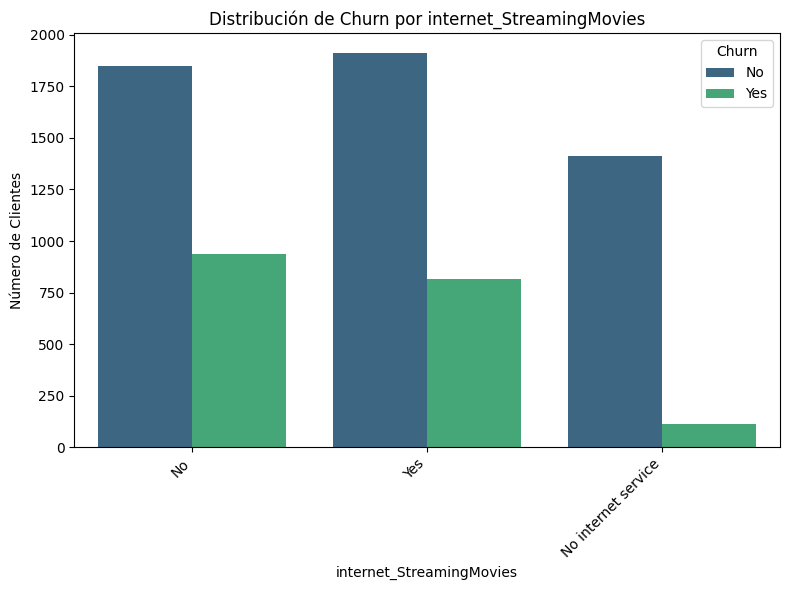

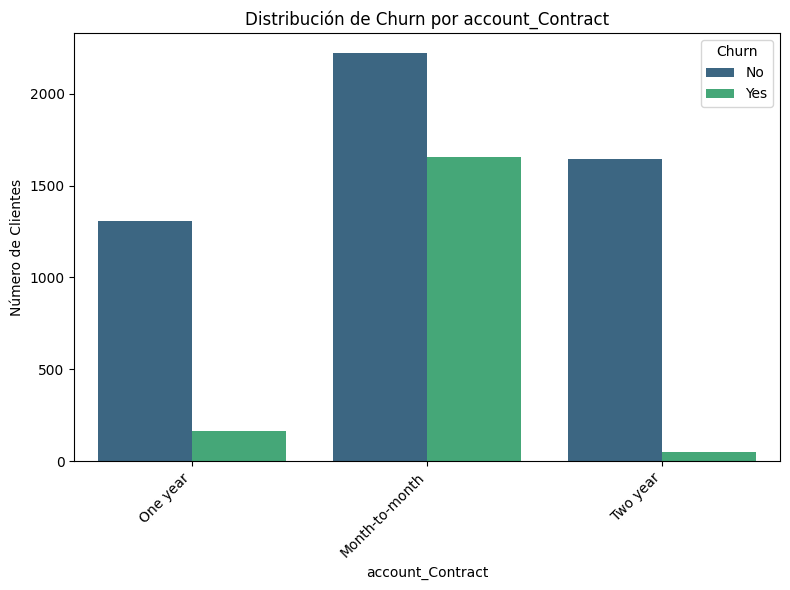

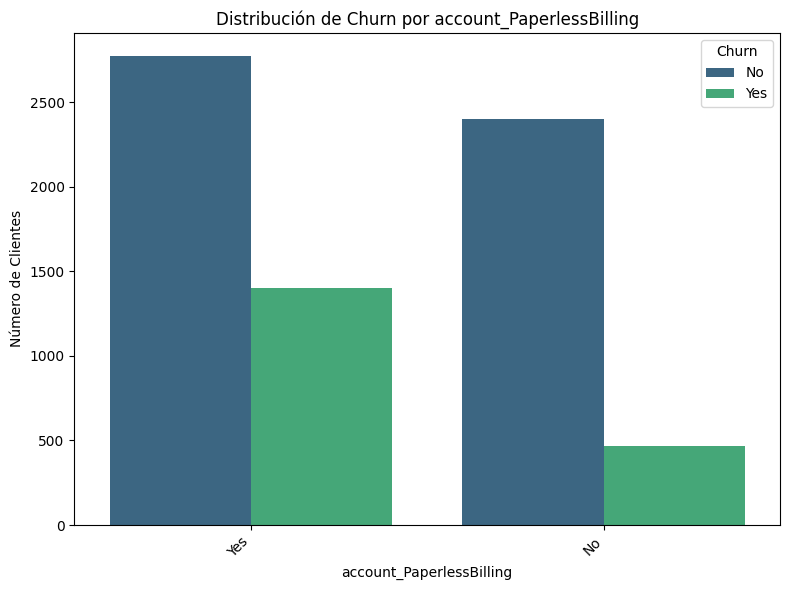

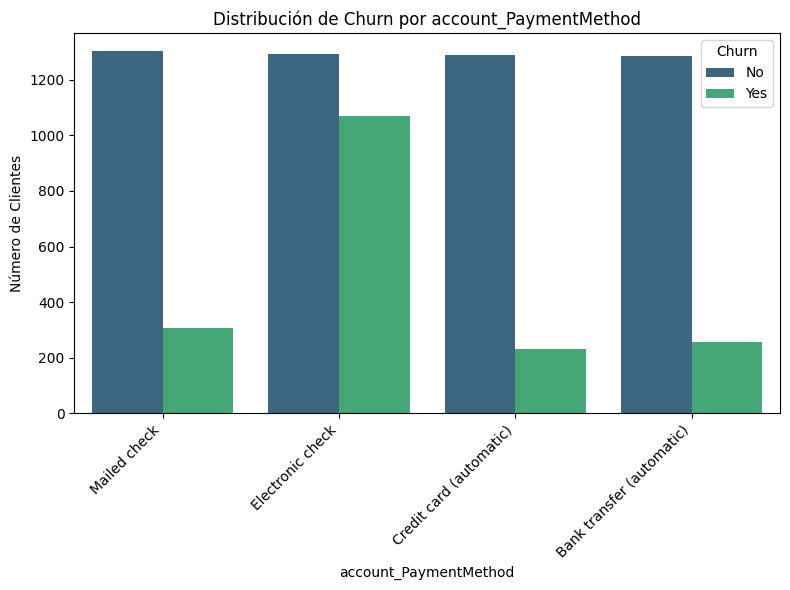

In [14]:
for column in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=column, hue='Churn', data=df, palette='viridis')
    plt.title(f'Distribución de Churn por {column}')
    plt.xlabel(column)
    plt.ylabel('Número de Clientes')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Análisis de Evasión por Variables Numéricas

Se examina la distribución de variables numéricas (como 'customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total') para clientes que han evadido versus los que no. Se utilizarán histogramas o boxplots para comparar las distribuciones y buscar patrones.


/tmp/ipykernel_191/1732866979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, y='Churn', data=df, palette='viridis')


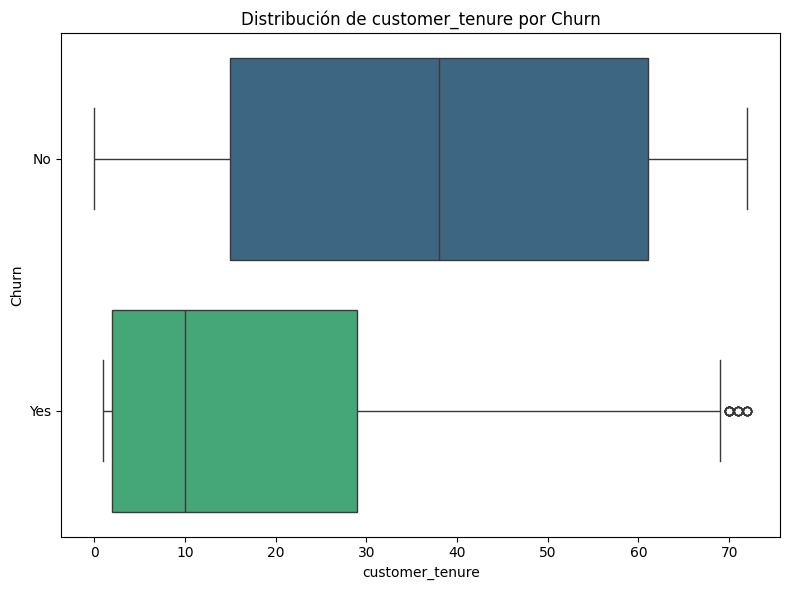

/tmp/ipykernel_191/1732866979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, y='Churn', data=df, palette='viridis')


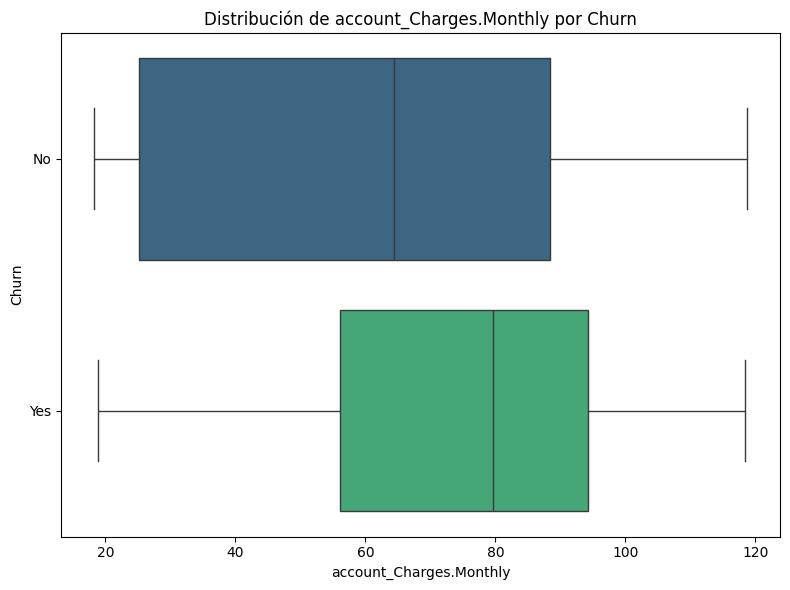

/tmp/ipykernel_191/1732866979.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=column, y='Churn', data=df, palette='viridis')


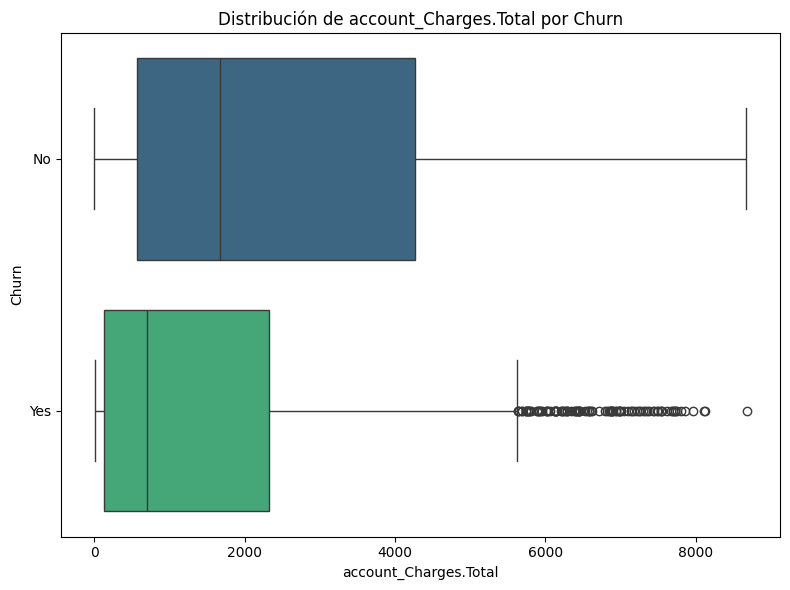

In [15]:
numerical_cols = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

for column in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, y='Churn', data=df, palette='viridis')
    plt.title(f'Distribución de {column} por Churn')
    plt.xlabel(column)
    plt.ylabel('Churn')
    plt.tight_layout()
    plt.show()

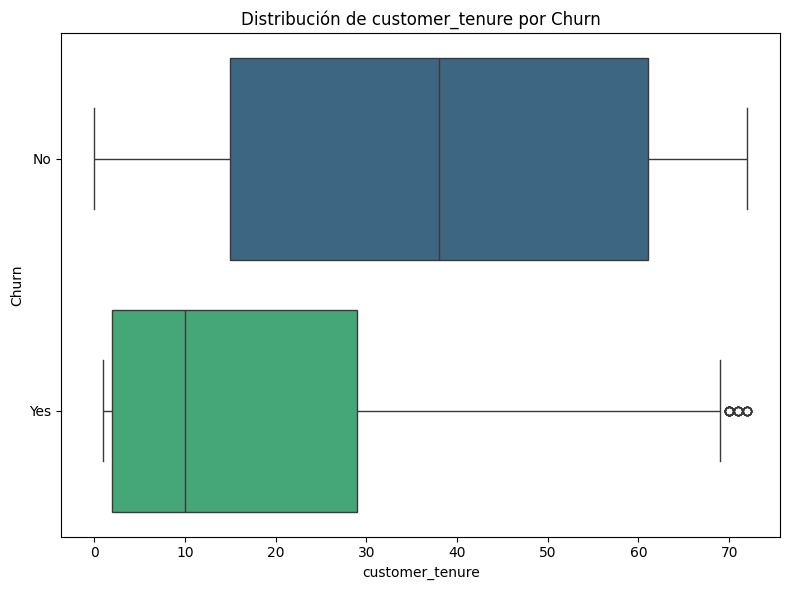

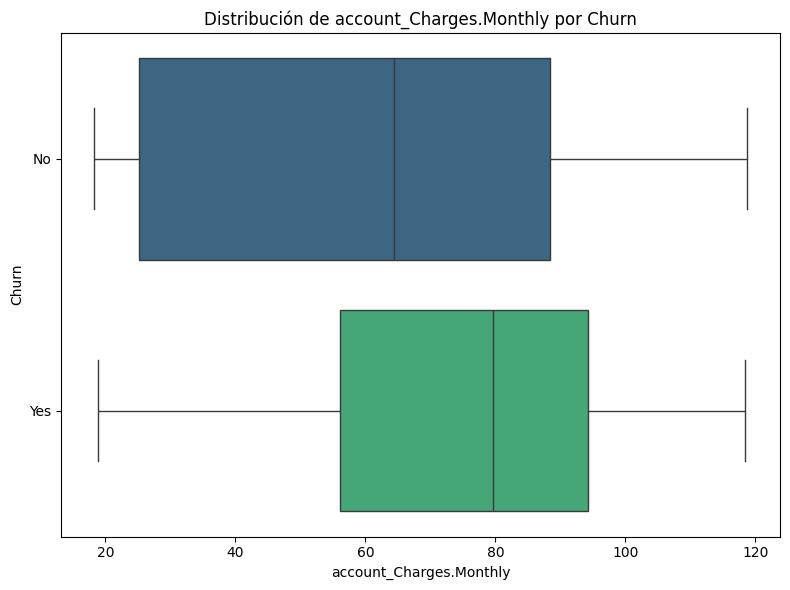

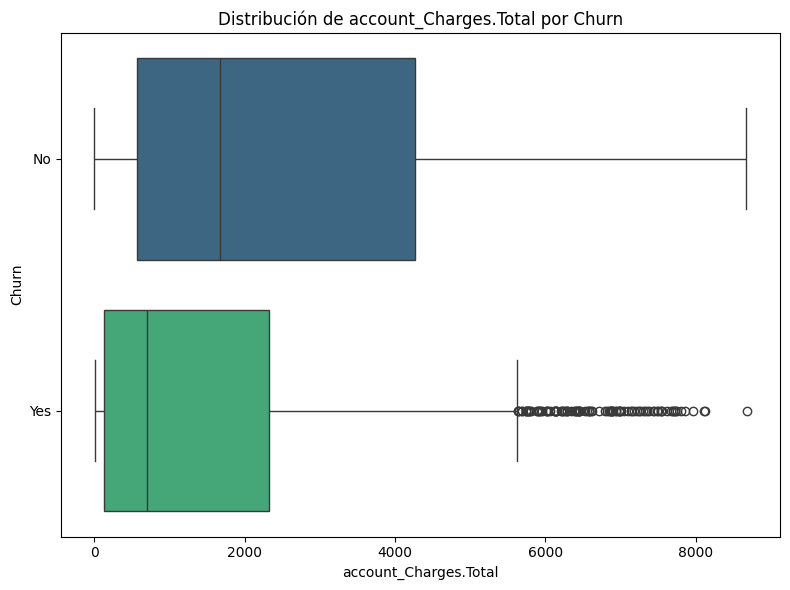

In [16]:
numerical_cols = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']

for column in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, y='Churn', hue='Churn', data=df, palette='viridis', legend=False)
    plt.title(f'Distribución de {column} por Churn')
    plt.xlabel(column)
    plt.ylabel('Churn')
    plt.tight_layout()
    plt.show()

## Informe Final y Conclusiones


### 1. Introducción

El problema de la evasión de clientes, conocido como 'Churn', es un desafío crítico para las empresas de telecomunicaciones. La pérdida de clientes no solo implica una reducción directa de ingresos, sino que también puede ser más costosa que la adquisición de nuevos clientes. Este informe tiene como objetivo principal identificar los factores clave que influyen en la decisión de un cliente de abandonar el servicio de telecomunicaciones. Mediante un análisis exploratorio de datos (EDA) detallado, buscaremos comprender los patrones de comportamiento de los clientes, sus características demográficas y el impacto de los servicios contratados, el tipo de contrato y los métodos de pago en la tasa de Churn. Al comprender estos factores, la empresa podrá desarrollar estrategias más efectivas para retener a sus clientes y mejorar la satisfacción general del servicio.

### 2. Limpieza y Tratamiento de Datos

El proceso de preparación de los datos fue fundamental para asegurar la calidad y fiabilidad de nuestro análisis. A continuación, se detallan los pasos clave:

*   **Extracción y Carga:** Los datos fueron cargados directamente desde una API en formato JSON y convertidos a un DataFrame de Pandas para su manipulación.
*   **Aplanamiento de Columnas Anidadas:** El dataset inicial contenía columnas anidadas ('customer', 'phone', 'internet', 'account') que almacenaban diccionarios. Estas columnas fueron aplanadas, extrayendo sus claves como nuevas columnas individuales (por ejemplo, `customer_gender`, `phone_PhoneService`, `internet_InternetService`, `account_Contract`) para facilitar el acceso y análisis de la información.
*   **Limpieza y Conversión de `account_Charges.Total`:** Se identificó que la columna `account_Charges.Total` era de tipo `object` a pesar de representar valores numéricos. Se detectaron y reemplazaron los espacios en blanco con valores `NaN`, para luego convertir la columna a tipo `float`. Los valores `NaN` restantes fueron imputados con `0`, asumiendo que representan clientes con 0 cargos totales (por ejemplo, clientes nuevos sin historial de facturación).
*   **Verificación de Valores Ausentes:** Tras las transformaciones, se realizó una verificación exhaustiva y se confirmó que el DataFrame no contenía valores nulos en ninguna de sus columnas, lo que garantiza la integridad de los datos para el análisis.
*   **Identificación de Filas Duplicadas:** Se verificó la existencia de filas completamente duplicadas en el DataFrame. Se confirmó que no había registros idénticos, asegurando la unicidad de cada observación.
*   **Corrección de Inconsistencias en `Churn`:** Durante la exploración de valores únicos en las columnas categóricas, se descubrió que la columna `Churn` contenía una cadena vacía (`''`) además de 'Yes' y 'No'. Dado que `Churn` es la variable objetivo y debe ser binaria, se decidió eliminar las filas que contenían este valor inconsistente para evitar sesgos en el análisis y modelado. Esto redujo el número de entradas de 7267 a 7043.

### 3. Análisis Exploratorio de Datos (EDA)

#### 3.1 Análisis Descriptivo General

Al revisar las estadísticas de las columnas numéricas (`df.describe()`), encontramos lo siguiente:

*   **`customer_SeniorCitizen`:** Aproximadamente el 16% de nuestros clientes son personas mayores. Este es un dato importante para entender los grupos que podrían estar abandonando el servicio.
*   **`customer_tenure`:** En promedio, los clientes permanecen con nosotros unos 32 meses. Sin embargo, hay mucha variación: algunos se van muy pronto (el 25% dura menos de 9 meses), mientras que otros se quedan mucho más tiempo (el 75% dura menos de 55 meses). Esta diferencia en la duración del contrato podría ser clave para el Churn.
*   **`account_Charges.Monthly`:** El cargo mensual promedio es de unos $64.76$. Los precios varían significativamente (desde $18.25$ hasta $118.75$), lo que indica que los clientes tienen diferentes paquetes de servicios.

*   **`account_Charges.Total`:** El total gastado por los clientes promedia $2283.30. También aquí hay una gran dispersión, desde cantidades muy bajas (probablemente clientes nuevos) hasta muy altas.

Para las columnas categóricas, observamos las siguientes tendencias:

*   **`Churn`:** Nuestra variable principal, 'Churn', muestra que la mayoría de los clientes (aproximadamente el 73.4%) se quedan, mientras que un 26.6% sí se va. Reducir este 26.6% es nuestro objetivo principal.
*   **`customer_gender`:** La distribución de clientes por género es casi igual entre hombres y mujeres.
*   **Servicios (Teléfono, Internet, Seguridad Online, etc.):** Hay clientes que no tienen ciertos servicios (por ejemplo, 'No phone service' o 'No internet service'). Entender esto es crucial, ya que la presencia o ausencia de un servicio puede influir en la decisión de irse.
*   **`account_Contract`:** La mayoría de los clientes tienen contratos 'Month-to-month' (mes a mes), seguidos por contratos de 'Two year' (dos años) y 'One year' (un año).
*   **`account_PaymentMethod`:** La forma de pago más común es 'Electronic check' (cheque electrónico).

#### 3.2 Distribución de Churn

La visualización de la variable `Churn` confirmó que, de los 7043 clientes, 5174 permanecen y 1869 han dejado la empresa. Esto subraya la importancia de identificar los motivos de la evasión.

#### 3.3 Churn por Variables Categóricas

El análisis detallado por categorías nos mostró lo siguiente:

*   **`customer_gender`:** No hay una diferencia clara en la tasa de Churn entre hombres y mujeres.
*   **`customer_SeniorCitizen`:** Los clientes mayores (`SeniorCitizen` = 1) tienen una tasa de Churn significativamente más alta que los clientes más jóvenes (`SeniorCitizen` = 0).
*   **`customer_Partner` y `customer_Dependents`:** Los clientes sin pareja (`Partner` = No) y sin dependientes (`Dependents` = No) son más propensos a irse.
*   **`phone_PhoneService` y `phone_MultipleLines`:** Tener o no servicio telefónico no impacta mucho en el Churn. Sin embargo, los clientes con múltiples líneas (`MultipleLines` = Yes) muestran una tasa de Churn ligeramente superior a los que tienen una sola línea o no tienen servicio telefónico.
*   **`internet_InternetService`:** Los clientes con servicio de 'Fiber optic' (fibra óptica) se van mucho más que los que tienen 'DSL' o no tienen internet. Esto es un punto crítico para la fibra óptica.
*   **Servicios adicionales de internet (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`):** Los clientes que no contratan servicios de seguridad online, respaldo o soporte técnico (`OnlineSecurity='No'`, `TechSupport='No'`) tienen una mayor tendencia a la evasión. Curiosamente, los clientes que no tienen *ningún* servicio de internet tienen la menor tasa de Churn, lo que sugiere que la calidad o el soporte de los servicios de internet son un factor importante.
*   **`account_Contract`:** Los contratos 'Month-to-month' (mes a mes) están muy relacionados con una alta tasa de Churn. Los contratos de 'One year' (un año) y especialmente los de 'Two year' (dos años) son mucho más estables y tienen tasas de Churn más bajas.
*   **`account_PaperlessBilling`:** Los clientes que optan por la factura sin papel (`PaperlessBilling='Yes'`) tienen una tasa de Churn más alta.
*   **`account_PaymentMethod`:** El 'Electronic check' (cheque electrónico) es el método de pago que más usan los clientes que se van.

#### 3.4 Churn por Variables Numéricas

Al analizar las variables numéricas en relación con el Churn, encontramos:

*   **`customer_tenure`:** Los clientes que se van (`Churn='Yes'`) tienden a llevar mucho menos tiempo con la empresa que los que se quedan. Esto nos dice que los clientes nuevos son los más vulnerables a la evasión.
*   **`account_Charges.Monthly`:** Los clientes que abandonan el servicio suelen tener cargos mensuales más altos que los que permanecen. Esto podría indicar que los altos costos mensuales son una fuente de insatisfacción.
*   **`account_Charges.Total`:** A pesar de tener cargos mensuales más altos, los clientes que se van tienen un total de cargos acumulados más bajo. Esto es lógico, ya que no han estado con la empresa por mucho tiempo. Este punto refuerza la idea de que los clientes nuevos con facturas mensuales elevadas están en mayor riesgo de irse

### 4. Conclusiones e Insights

El análisis exploratorio de datos ha revelado patrones claros y accionables que contribuyen a la evasión de clientes. Los principales insights son:

*   **Vulnerabilidad de clientes nuevos y con contratos mensuales:** Los clientes con menor tiempo de contrato (`customer_tenure`) y aquellos con contratos mes a mes (`Month-to-month`) son significativamente más propensos a la evasión. Esto sugiere que los primeros meses de servicio y la falta de un compromiso a largo plazo son puntos críticos para la retención.
*   **Servicios de Internet de Fibra óptica y ausencia de servicios adicionales:** Los clientes que utilizan servicio de internet de Fibra óptica (`Fiber optic`) muestran una alta tasa de Churn. Además, la falta de servicios de valor agregado como seguridad en línea (`OnlineSecurity`), respaldo en línea (`OnlineBackup`) o soporte técnico (`TechSupport`) se asocia con mayor evasión. Esto implica que la calidad o percepción del servicio de fibra, o la ausencia de protecciones y soporte, podrían ser puntos de fricción.
*   **Impacto de los cargos mensuales y método de pago:** Los clientes que evaden tienden a tener cargos mensuales (`account_Charges.Monthly`) más altos. El método de pago `Electronic check` también se correlaciona con una mayor tasa de Churn. Esto podría indicar insatisfacción con la relación calidad-precio o problemas con la facilidad del pago.
*   **Demografía específica:** Los `SeniorCitizen` y los clientes sin `Partner` ni `Dependents` muestran una mayor propensión a la evasión. Estos segmentos demográficos podrían tener necesidades o expectativas diferentes que no están siendo satisfechas.

Estos insights son valiosos para la empresa, ya que señalan áreas específicas donde se pueden implementar intervenciones dirigidas para mejorar la retención de clientes y, en óltima instancia, la rentabilidad.

### 5. Recomendaciones Estratégicas

Basado en los hallazgos del análisis, se proponen las siguientes recomendaciones estratégicas para reducir la evasión de clientes:

1.  **Programas de Retención para Clientes Nuevos:** Implementar programas de bienvenida y seguimiento proactivo durante los primeros 6-9 meses de servicio para clientes con baja `customer_tenure`, especialmente aquellos con contratos mes a mes. Ofrecer incentivos para la conversión a contratos más largos (1 o 2 años), como descuentos o mejoras de servicio gratuitas por un período.
2.  **Mejora de la Experiencia con Fibra Óptica y Servicios Adicionales:** Investigar las causas subyacentes de la alta evasión en clientes con `Fiber optic`. Podría ser necesario mejorar la calidad del servicio, la atención al cliente o la comunicación de beneficios. Adicionalmente, promover activamente los servicios de seguridad y soporte en línea (`OnlineSecurity`, `OnlineBackup`, `TechSupport`) a clientes que actualmente no los tienen, destacando su valor y beneficios para la estabilidad del servicio.
3.  **Optimización de Planes y Costos:** Revisar la estructura de precios de los planes con cargos mensuales elevados (`account_Charges.Monthly`) para asegurar que sean competitivos y perceivedos como justos por los clientes. Considerar ofrecer bundles o planes más flexibles que se ajusten a diferentes necesidades y presupuestos.
4.  **Revisión del Proceso de Pago con Cheque Electrónico:** Analizar la experiencia de los clientes que utilizan `Electronic check` como método de pago. Identificar posibles fricciones o problemas que podrían llevar a la insatisfacción y, por ende, a la evasión. Ofrecer alternativas más cómodas o seguras si es necesario.
5.  **Marketing y Ofertas Segmentadas:** Diseñar campañas de marketing y ofertas personalizadas para segmentos demográficos vulnerables, como los `SeniorCitizen` y clientes sin `Partner` ni `Dependents`. Entender sus necesidades específicas (por ejemplo, soporte técnico más accesible o planes simplificados) y comunicarles cómo los servicios de la empresa pueden satisfacerlas.